In [1]:
# Assignment 2: From Trees to Neural Networks
# COMS 4995 Applied Machine Learning — Spring 2026

import os
os.environ["PYTHONWARNINGS"] = "ignore"       # inherited by joblib worker processes
os.environ["XGBOOST_VERBOSITY"] = "0"         # suppress XGBoost C-level messages

import warnings
warnings.filterwarnings("ignore")

import numpy as np
np.seterr(all="ignore")                       # suppress numpy C-level RuntimeWarnings

from src.utils import set_global_seed, setup_plotting, timer
from src.data_preparation import prepare_data, load_data, inspect_data, clean_data
from src.gbdt_model import train_gbdt, tune_gbdt, plot_training_validation_loss, plot_feature_importance, plot_learning_rate_comparison
from src.mlp_model import train_mlp, tune_mlp, plot_training_loss_curve, plot_depth_width_comparison
from src.mlp_model import plot_learning_rate_comparison as mlp_plot_lr
from src.evaluation import (
    build_comparison_table, plot_confusion_matrices, plot_pr_curves,
    print_classification_reports,
)

set_global_seed()
setup_plotting()
print("All modules loaded successfully.")

All modules loaded successfully.


## 1. Data Preparation

Load the UCI Bank Marketing dataset, handle missing values, encode categorical features, engineer new features, and split into train/validation/test sets (70/15/15, stratified). StandardScaler is fit on the training set only for MLP use.

In [2]:
# === 1. DATA PREPARATION ===
data = prepare_data()

X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]
X_train_scaled = data["X_train_scaled"]
X_val_scaled = data["X_val_scaled"]
X_test_scaled = data["X_test_scaled"]

print(f"\nFeature count: {len(data['feature_names'])}")
print(f"Class balance — Positive: {y_train.mean():.3f}, Negative: {1 - y_train.mean():.3f}")

Loaded dataset: 41188 rows, 21 columns

--- Data Types ---
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

--- Descriptive Statistics ---
                age     job  marital          education default housing  \
count   41188.00000   41188    41188              41188   41188   41188   
unique          NaN      12        4                  8       3       3   
top             NaN  admin.  married  university.degree      no     yes   
freq            NaN   10422    24928             

## 2. Gradient Boosted Decision Trees (XGBoost)

Hyperparameter tuning via RandomizedSearchCV (30 iterations, 3-fold CV, F1 scoring). Parameters explored: learning_rate, n_estimators, max_depth, subsample, reg_alpha, reg_lambda. Class imbalance handled with `scale_pos_weight`.

In [3]:
# === 2. GRADIENT BOOSTED DECISION TREES ===

import time

# Hyperparameter tuning
print("Tuning GBDT hyperparameters...")
start = time.time()
gbdt_model, gbdt_search = tune_gbdt(X_train, y_train, X_val, y_val)
gbdt_time = time.time() - start
print(f"\nGBDT total tuning + training time: {gbdt_time:.2f}s")

Tuning GBDT hyperparameters...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.1}
Best CV F1: 0.6318

GBDT total tuning + training time: 15.14s


### GBDT Visualizations

Training vs. validation loss, feature importance (gain), and learning rate comparison (lr = 0.01, 0.1, 0.3).

--- Training vs. Validation Loss ---
Saved: figures/gbdt_train_val_loss.png


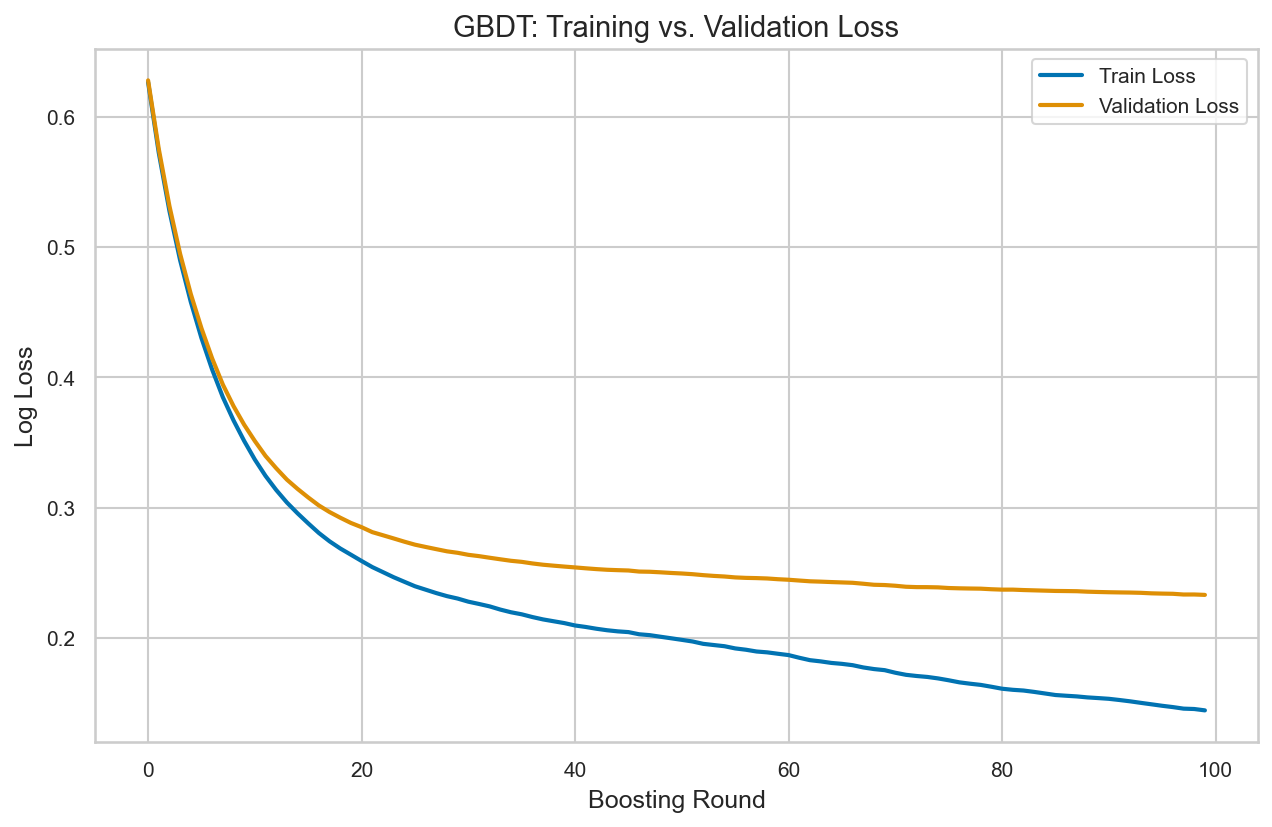


--- Feature Importance ---
Saved: figures/gbdt_feature_importance.png


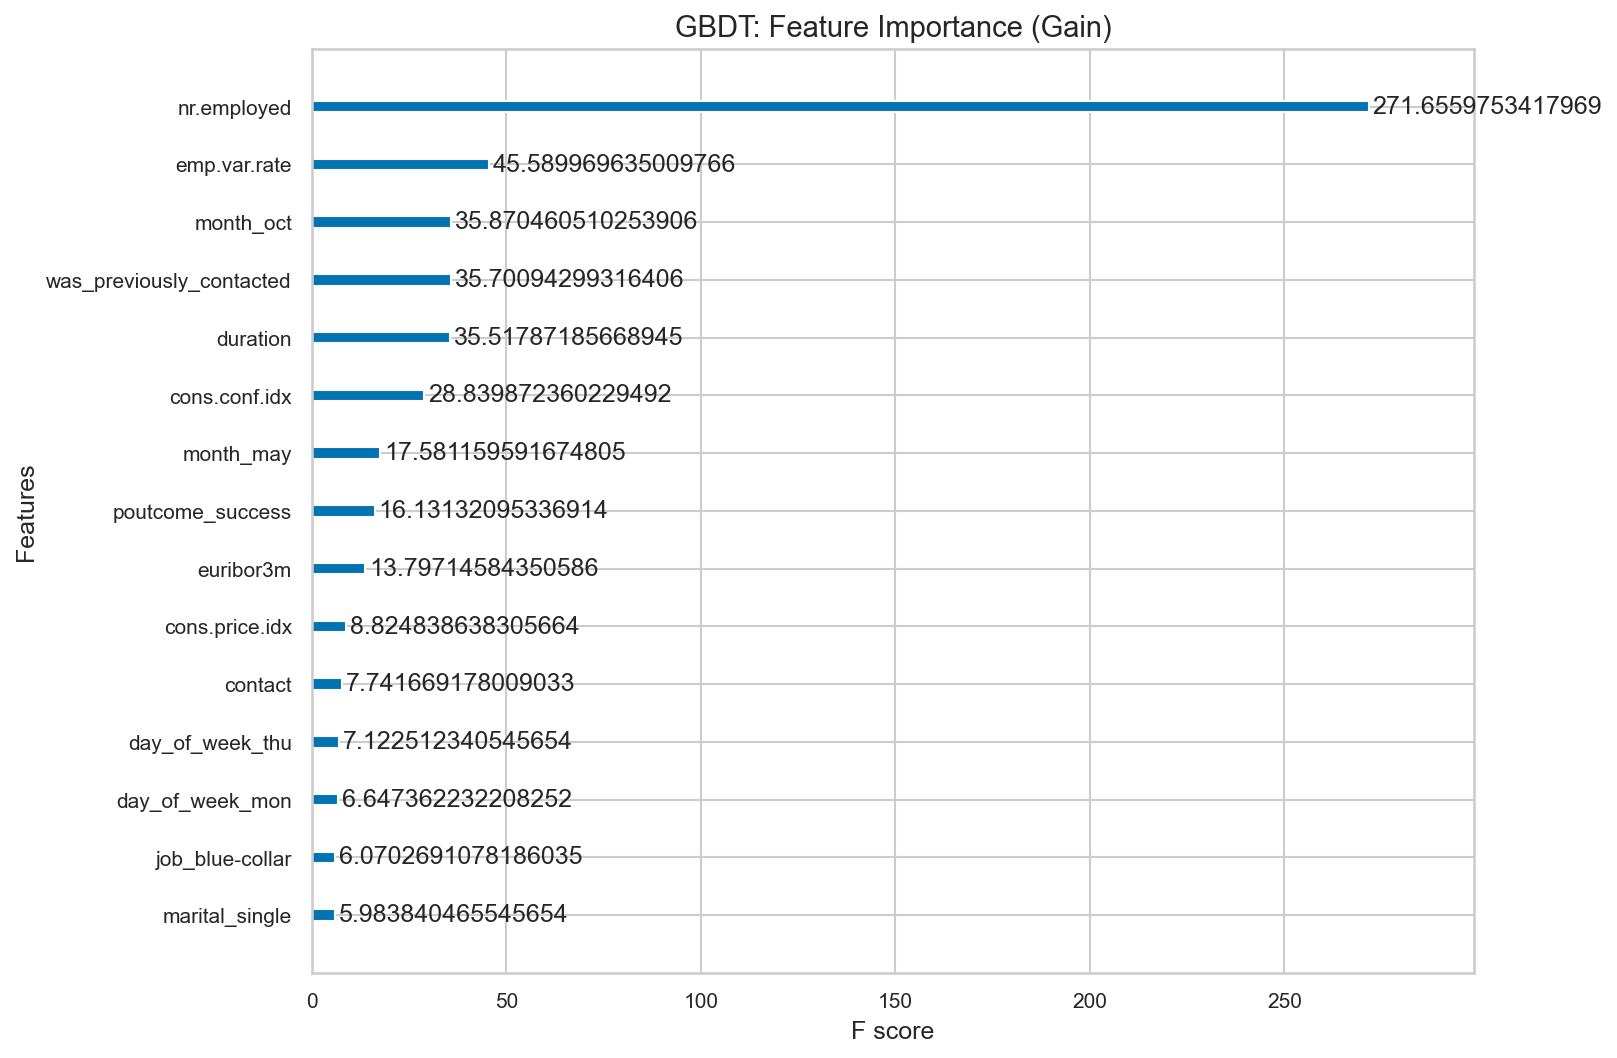


--- Learning Rate Comparison ---
Saved: figures/gbdt_learning_rate_comparison.png


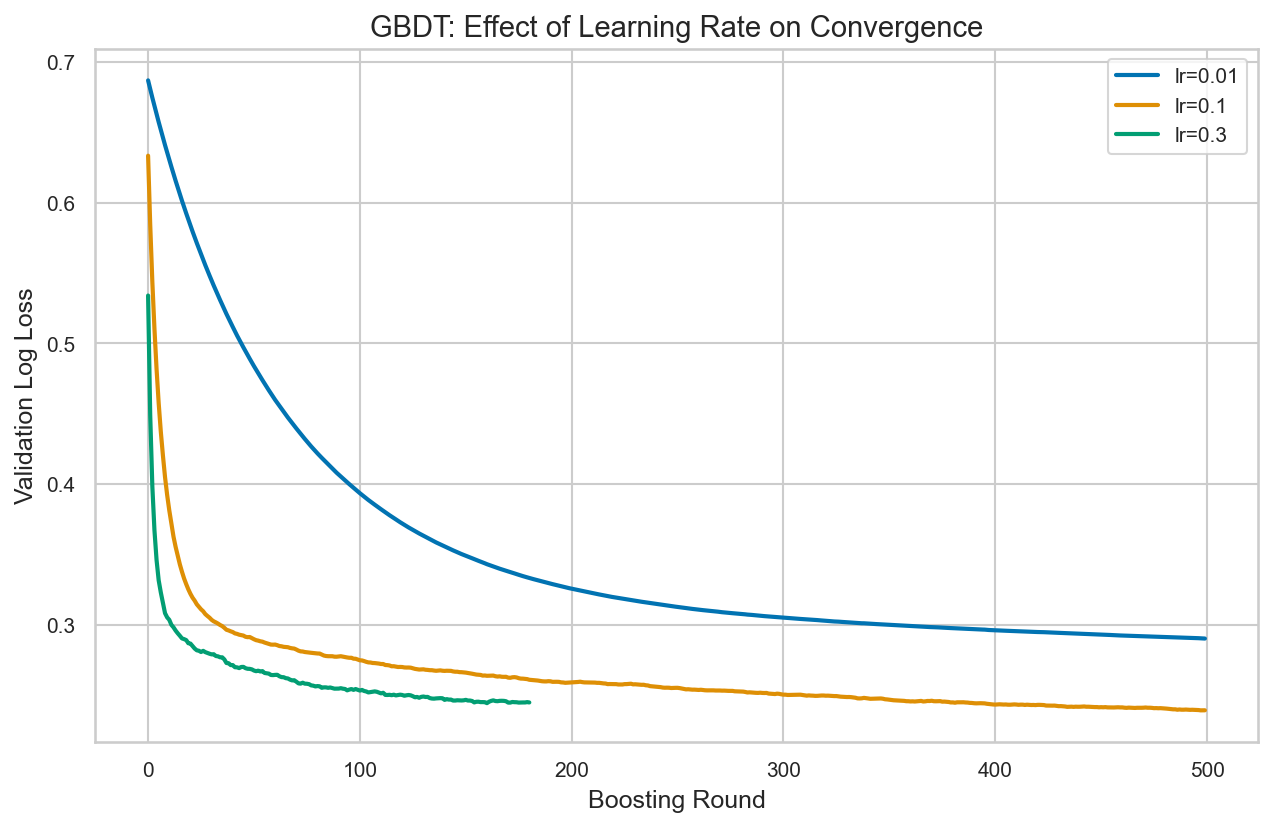

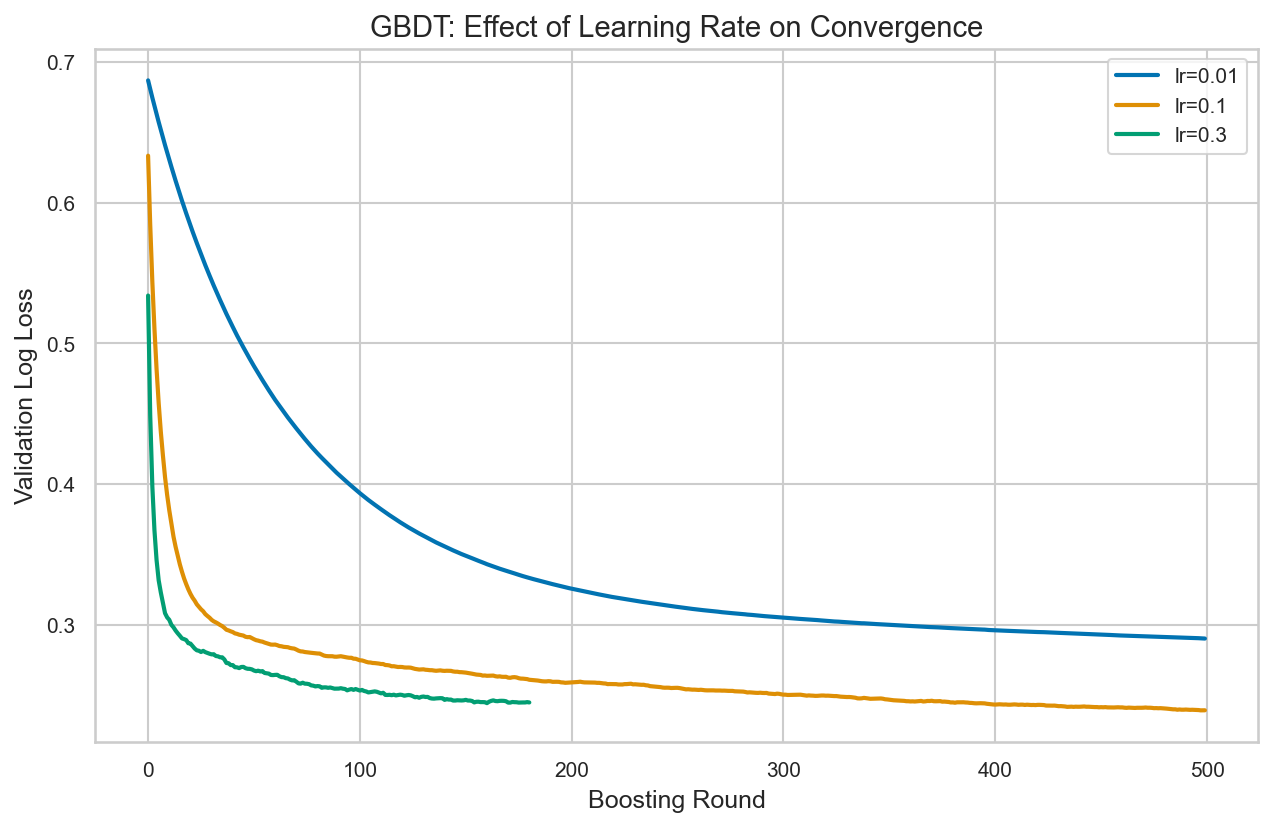

In [4]:
# GBDT Visualizations
print("--- Training vs. Validation Loss ---")
plot_training_validation_loss(gbdt_model)

print("\n--- Feature Importance ---")
plot_feature_importance(gbdt_model)

print("\n--- Learning Rate Comparison ---")
plot_learning_rate_comparison(X_train, y_train, X_val, y_val)

## 3. Multi-Layer Perceptron (sklearn)

Hyperparameter tuning via RandomizedSearchCV (30 iterations, 3-fold CV, F1 scoring). Parameters explored: hidden_layer_sizes, activation, learning_rate_init, alpha, max_iter. Features standardized with StandardScaler (fit on train only).

In [5]:
# === 3. MULTI-LAYER PERCEPTRON ===

print("Tuning MLP hyperparameters...")
start = time.time()
mlp_model, mlp_search = tune_mlp(X_train_scaled, y_train)
mlp_time = time.time() - start
print(f"\nMLP total tuning + training time: {mlp_time:.2f}s")

Tuning MLP hyperparameters...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params: {'max_iter': 1000, 'learning_rate_init': 0.01, 'hidden_layer_sizes': (256, 128), 'alpha': 0.01, 'activation': 'tanh'}
Best CV F1: 0.5819

MLP total tuning + training time: 37.33s


### MLP Visualizations

Training loss curve with validation score, depth/width comparison across architectures, and learning rate comparison (lr = 0.001, 0.01, 0.1).

--- Training Loss Curve ---
Saved: figures/mlp_training_loss.png


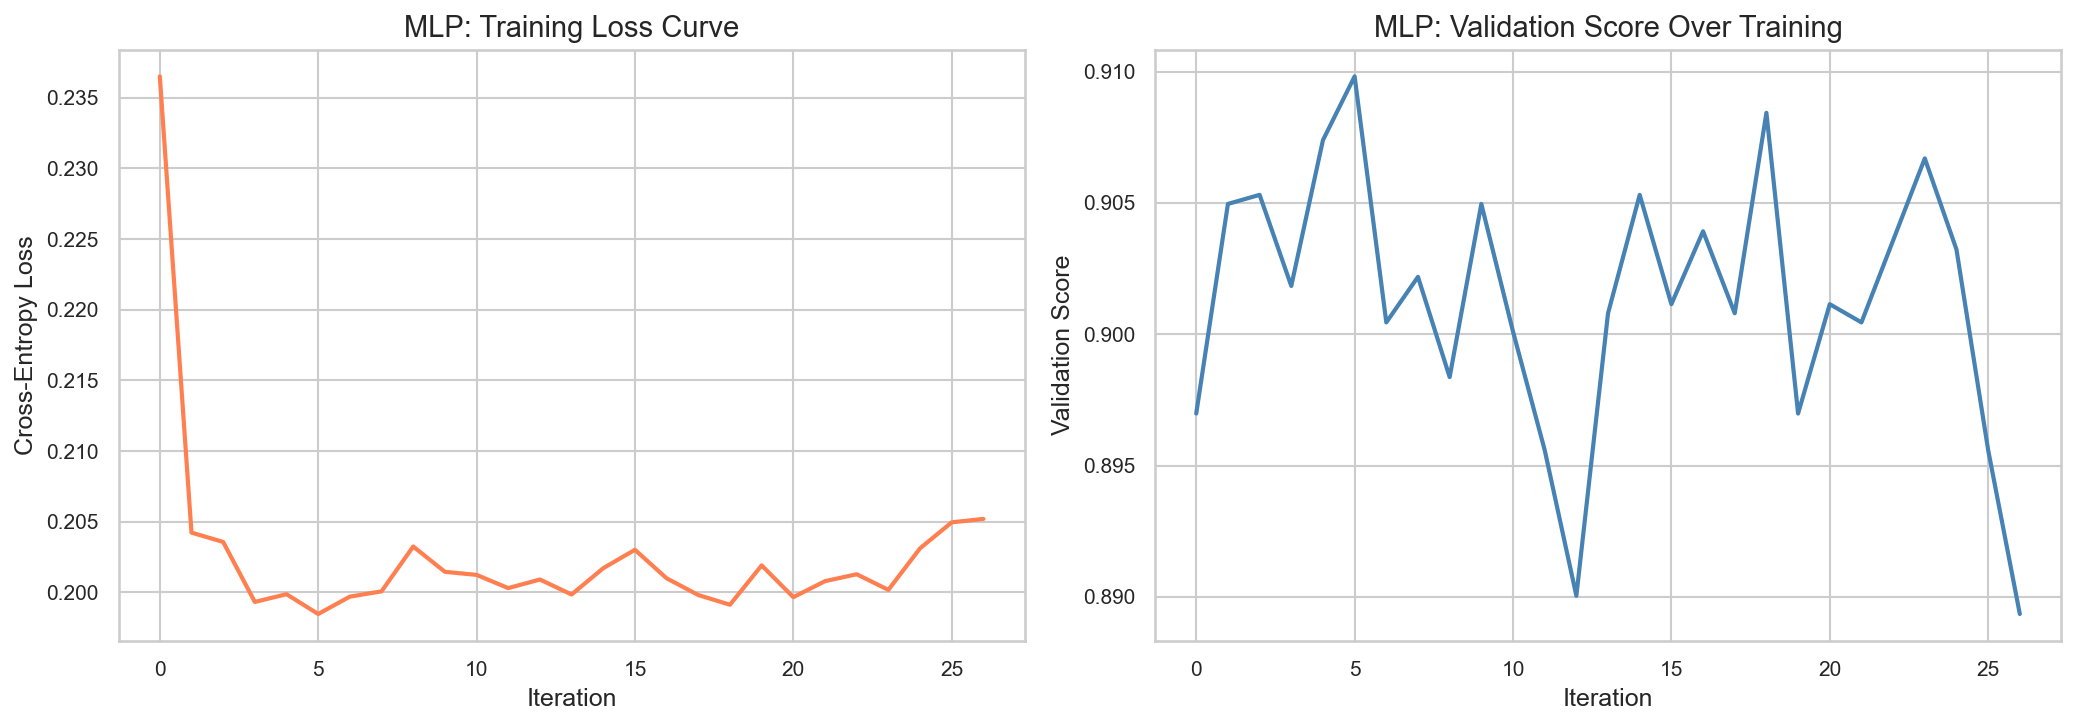


--- Depth/Width Comparison ---
  (64,): Val F1 = 0.5653
  (128, 64): Val F1 = 0.5787
  (256, 128, 64): Val F1 = 0.5679
Saved: figures/mlp_depth_width_comparison.png


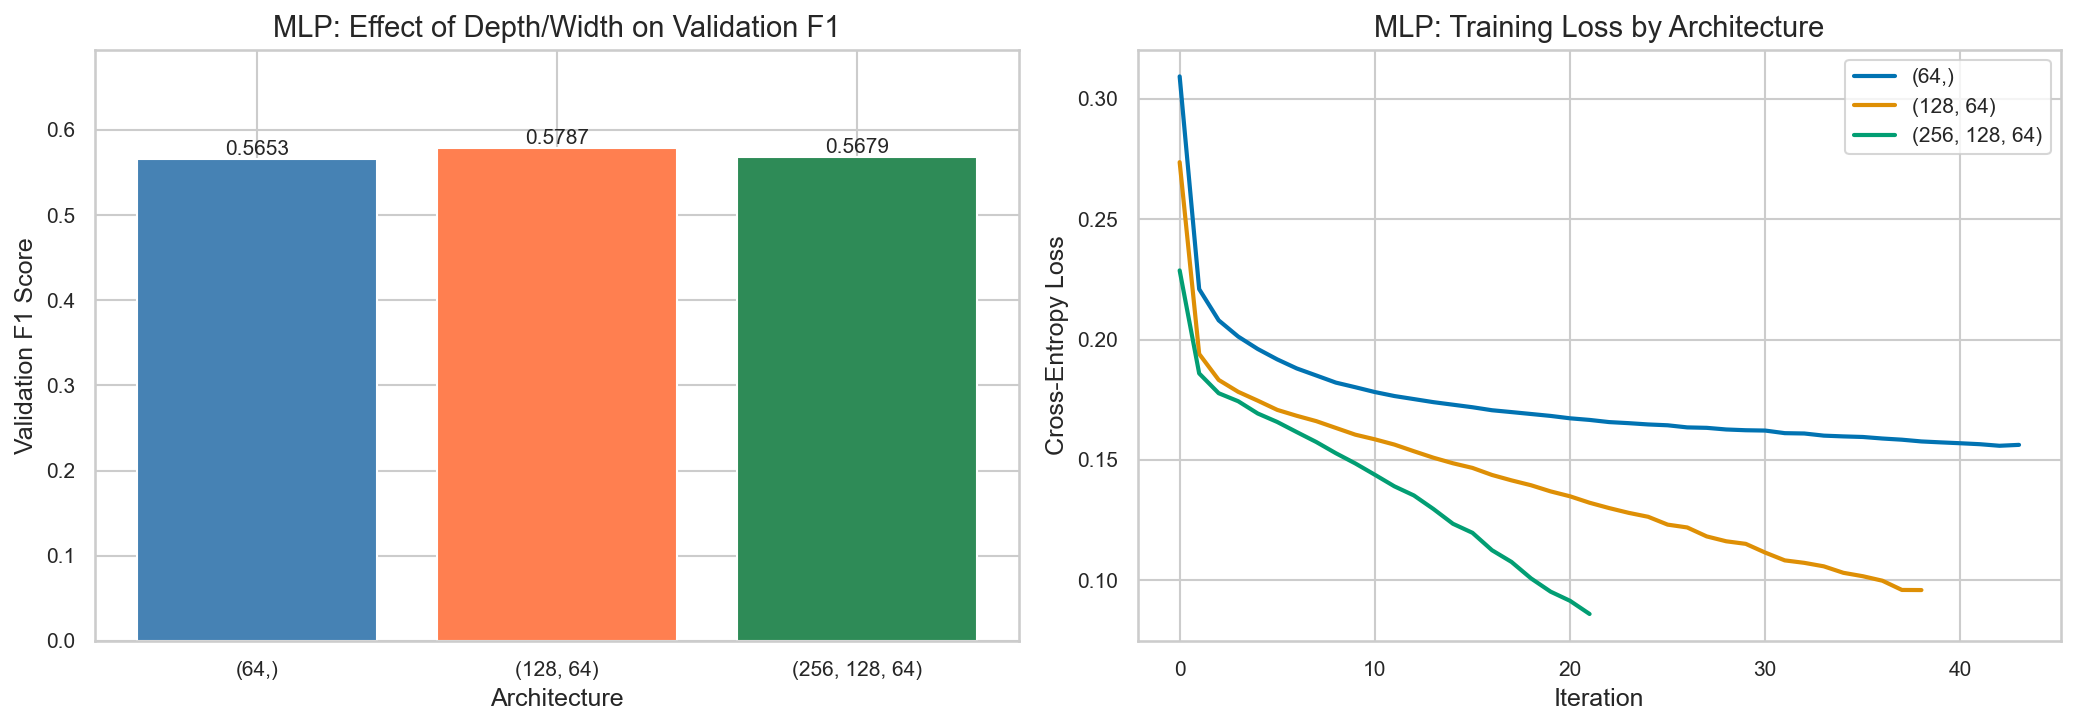


--- Learning Rate Comparison ---
  lr=0.001: Val F1 = 0.5787, iterations = 39
  lr=0.01: Val F1 = 0.5644, iterations = 28
  lr=0.1: Val F1 = 0.5115, iterations = 23
Saved: figures/mlp_learning_rate_comparison.png


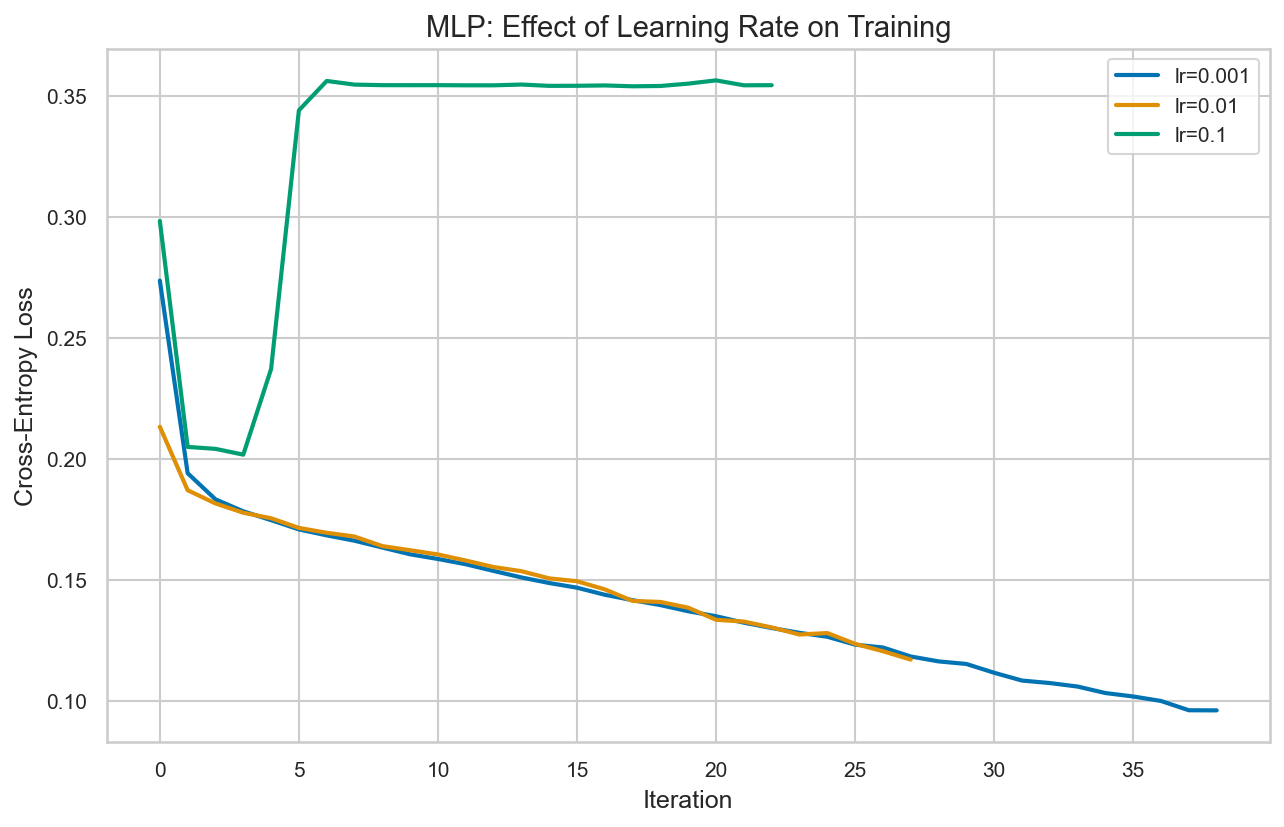

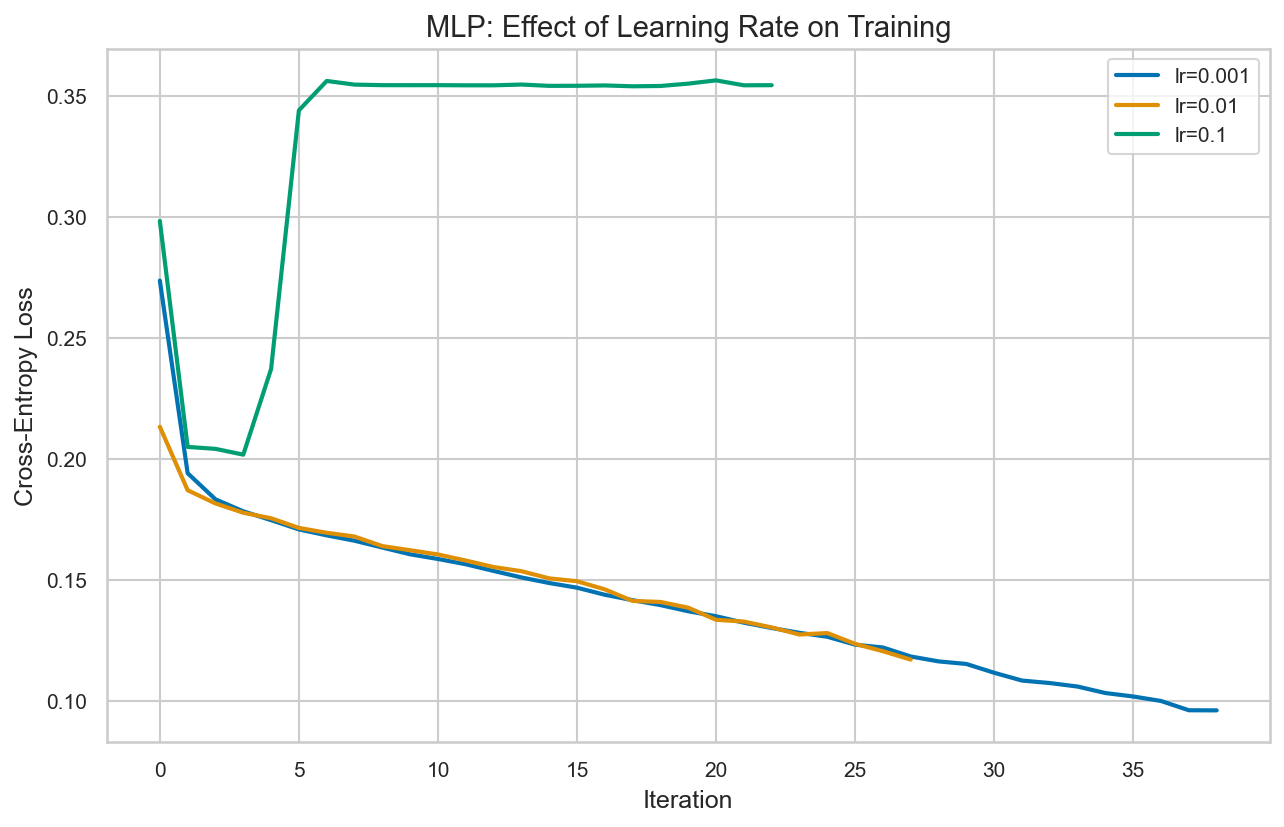

In [6]:
# MLP Visualizations
print("--- Training Loss Curve ---")
plot_training_loss_curve(mlp_model)

print("\n--- Depth/Width Comparison ---")
plot_depth_width_comparison(X_train_scaled, y_train, X_val_scaled, y_val)

print("\n--- Learning Rate Comparison ---")
mlp_plot_lr(X_train_scaled, y_train, X_val_scaled, y_val)

### Why Scaling Matters for MLP (but not GBDT)

Quick experiment: train MLP with the same best params on unscaled vs. scaled features. Trees split on feature ordering (scale-invariant), but neural networks compute weighted sums where large-magnitude features dominate gradients (L7).

In [7]:
# MLP: scaled vs unscaled features (same best params)
from sklearn.metrics import f1_score, confusion_matrix

best_mlp_params = mlp_search.best_params_

mlp_scaled = train_mlp(X_train_scaled, y_train, params=best_mlp_params)
mlp_unscaled = train_mlp(X_train, y_train, params=best_mlp_params)

f1_scaled = f1_score(y_val, mlp_scaled.predict(X_val_scaled))
y_hat_unscaled = mlp_unscaled.predict(X_val)
f1_unscaled = f1_score(y_val, y_hat_unscaled)

print("=== MLP: Effect of Feature Scaling ===")
print(f"  With StandardScaler:    Val F1 = {f1_scaled:.4f}")
print(f"  Without scaling:        Val F1 = {f1_unscaled:.4f}")
print(f"  Difference:             {f1_scaled - f1_unscaled:+.4f}")

# Sanity check: confirm unscaled MLP collapses to majority-class predictions
print(f"\n  Unscaled positive prediction rate: {y_hat_unscaled.mean():.4f}")
print(f"  Unscaled confusion matrix:\n{confusion_matrix(y_val, y_hat_unscaled)}")
print(f"\nConclusion: Without scaling, MLP collapses to predicting only the majority class (F1=0).")

=== MLP: Effect of Feature Scaling ===
  With StandardScaler:    Val F1 = 0.5417
  Without scaling:        Val F1 = 0.0000
  Difference:             +0.5417

  Unscaled positive prediction rate: 0.0000
  Unscaled confusion matrix:
[[5483    0]
 [ 696    0]]

Conclusion: Without scaling, MLP collapses to predicting only the majority class (F1=0).


## 4. GBDT vs MLP Comparison

Side-by-side evaluation on the held-out test set: Accuracy, Precision, Recall, F1-score, AUC-PR, and training time.

In [8]:
# === 4. GBDT vs MLP COMPARISON ===

# Predictions
gbdt_pred = gbdt_model.predict(X_test)
gbdt_prob = gbdt_model.predict_proba(X_test)[:, 1]

mlp_pred = mlp_model.predict(X_test_scaled)
mlp_prob = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Comparison table
comparison = build_comparison_table(
    y_test, gbdt_pred, gbdt_prob, mlp_pred, mlp_prob, gbdt_time, mlp_time
)


=== GBDT vs MLP Comparison ===
                  GBDT (XGBoost) MLP (sklearn)
Accuracy                  0.8951        0.9176
Precision                 0.5211        0.6837
Recall                    0.8534        0.5000
F1-score                  0.6471        0.5776
AUC-PR                    0.6766        0.6653
Training Time (s)          15.14         37.33


### Evaluation Visualizations

Classification reports, confusion matrices, and precision-recall curves for both models.

--- Classification Reports ---

=== GBDT Classification Report ===
              precision    recall  f1-score   support

          No       0.98      0.90      0.94      5483
         Yes       0.52      0.85      0.65       696

    accuracy                           0.90      6179
   macro avg       0.75      0.88      0.79      6179
weighted avg       0.93      0.90      0.91      6179


=== MLP Classification Report ===
              precision    recall  f1-score   support

          No       0.94      0.97      0.95      5483
         Yes       0.68      0.50      0.58       696

    accuracy                           0.92      6179
   macro avg       0.81      0.74      0.77      6179
weighted avg       0.91      0.92      0.91      6179


--- Confusion Matrices ---
Saved: figures/confusion_matrices.png


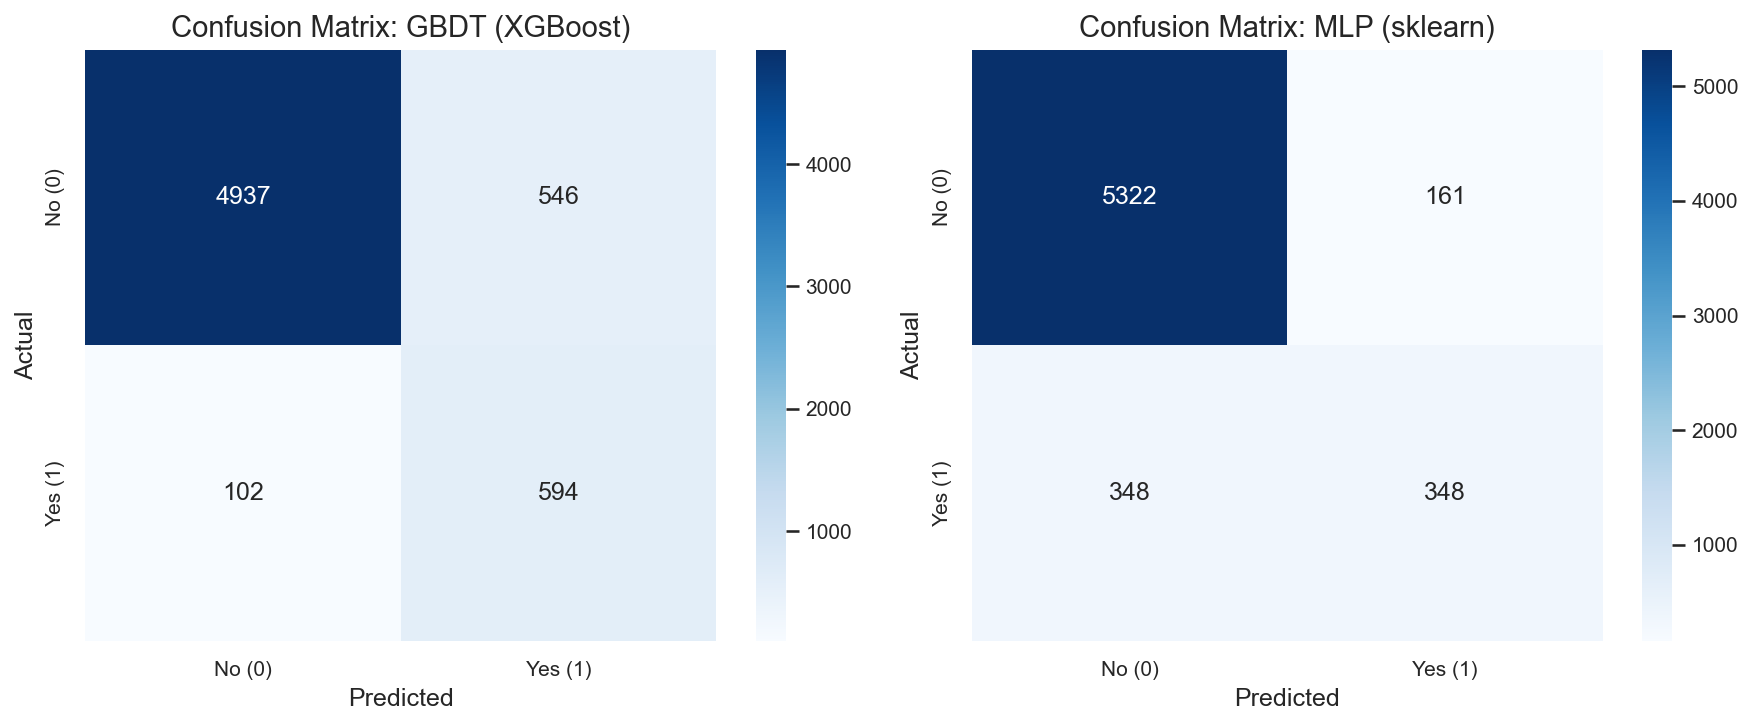


--- Precision-Recall Curves ---
Saved: figures/pr_curves.png


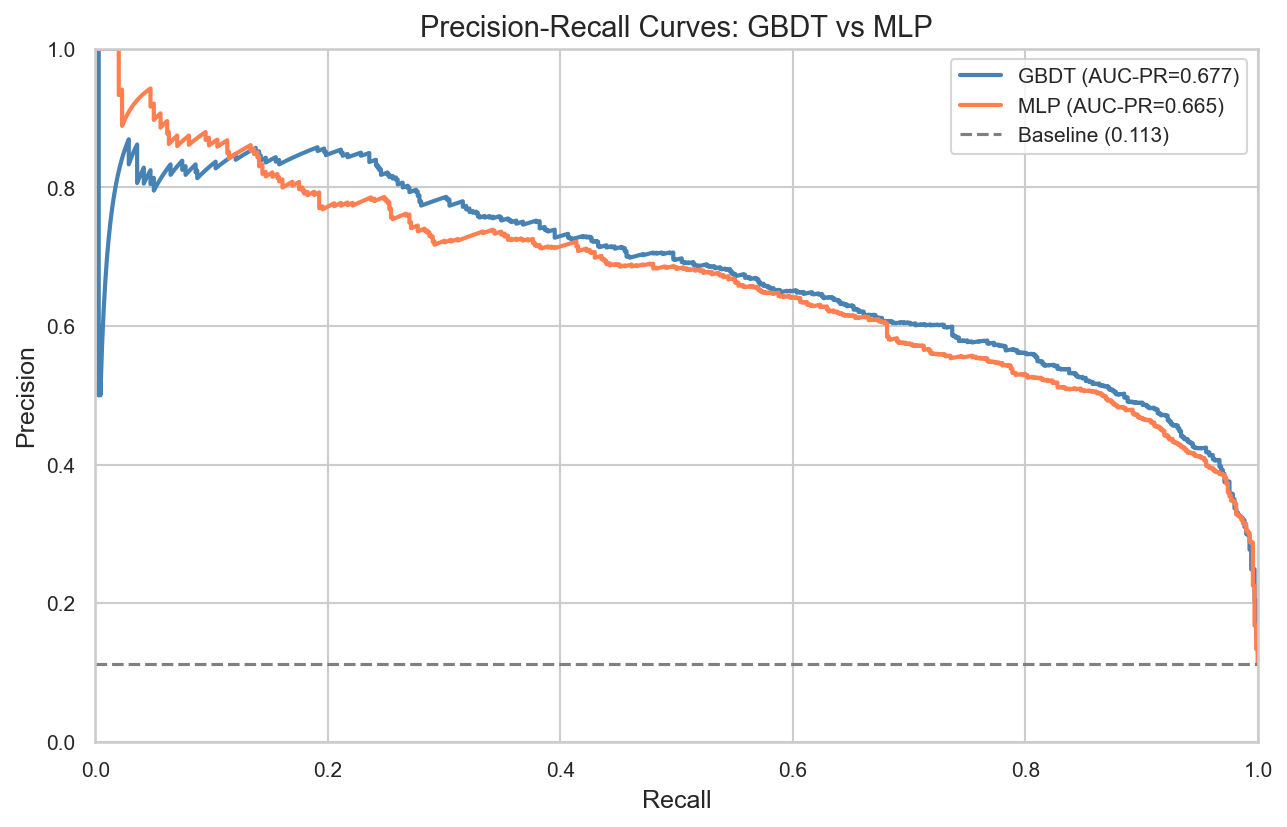

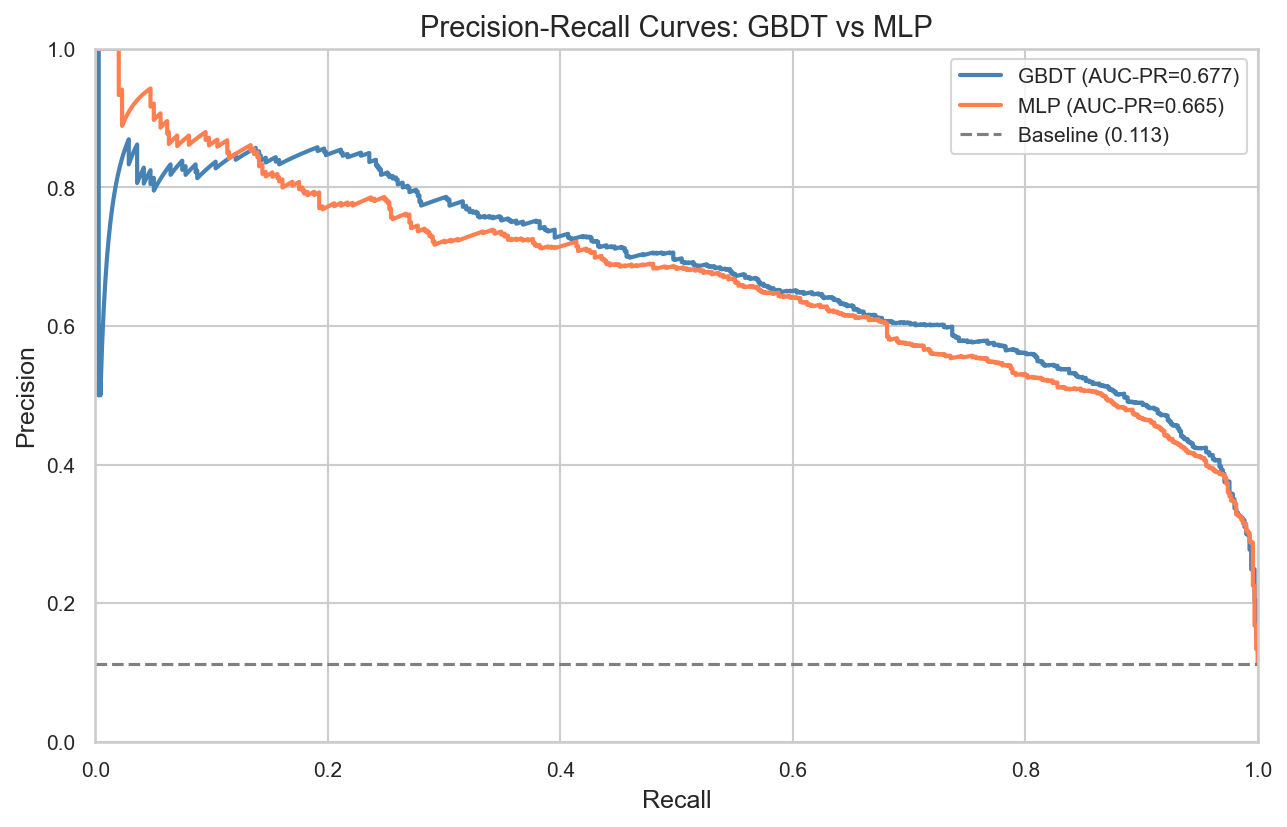

In [9]:
# === 5. EVALUATION & VISUALIZATION ===

print("--- Classification Reports ---")
print_classification_reports(y_test, gbdt_pred, mlp_pred)

print("\n--- Confusion Matrices ---")
plot_confusion_matrices(y_test, gbdt_pred, mlp_pred)

print("\n--- Precision-Recall Curves ---")
plot_pr_curves(y_test, gbdt_prob, mlp_prob)

In [10]:
# === SUMMARY ===
print("\n" + "="*60)
print("ASSIGNMENT 2 COMPLETE — All visualizations saved to figures/")
print("="*60)
print(f"\nBest GBDT params: {gbdt_search.best_params_}")
print(f"Best MLP params:  {mlp_search.best_params_}")
print(f"\nGBDT Test F1: {comparison.loc['F1-score', 'GBDT (XGBoost)']}")
print(f"MLP  Test F1: {comparison.loc['F1-score', 'MLP (sklearn)']}")


ASSIGNMENT 2 COMPLETE — All visualizations saved to figures/

Best GBDT params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.1}
Best MLP params:  {'max_iter': 1000, 'learning_rate_init': 0.01, 'hidden_layer_sizes': (256, 128), 'alpha': 0.01, 'activation': 'tanh'}

GBDT Test F1: 0.6471
MLP  Test F1: 0.5776


## AI Tool Usage Disclosure

**Tool used:** Claude Code (Anthropic) — CLI-based AI coding assistant.

**How it was used:**
- Project scaffolding and modular repo structure
- Code generation for data preparation, model training, evaluation, and visualization modules
- Hyperparameter search configuration and debugging
- Cross-referencing implementation against assignment requirements and lecture content

**Personal contributions:**
- Dataset selection decision and analysis
- Interpretation of all results and findings
- All report writing, analysis narratives, and bias-variance reasoning
- Hyperparameter tuning rationale and evaluation metric choices
- Review and validation of all generated code